pystran - Python package for structural analysis with trusses and beams

(C) 2025-2026, Petr Krysl, pkrysl@ucsd.edu

# A 2-D truss sizing optimization: Basic approach.

Last updated: 06/25/26

## Description

Optimize the cross sectional areas of a truss structure to achieve its 
minimum weight. Each bar can have a different cross section area.

Objective function: mass of the structure. The design variables are 
the relative cross sectional areas of each bar (17 in total).

Constraints: 
    (1) limit on maximum deflection, and 
    (2) the design variables (i.e. the cross sectional areas) are 
    bounded from below (so that they are greater than zero).

Mathematically
$$
       x^* = \arg\min f(x)
$$
subject to the constraint
$$
    c_j(x) \ge 0 \; , j=1,2
$$
Note: $f(x)$ is the objective function, whose argument is the vector of the design variables, $x$.
Here the design variables have the meaning of relative areas, in other words the area of a bar
$j$ is $A_j = x_j \times \verb!INITIAL_AREA!$.



Now we describe the implementation. First we bring in the modules and functions that we will need.

In [108]:
import context
from numpy import max, ones
from pystran import model
from pystran import section
from pystran import plots
from scipy.optimize import minimize

We are working in SI(mm) units. Next, we define some useful constants.

Initially, all members have cross sections of these dimensions (in millimeters square).

In [109]:
INITIAL_AREA = 150.0

The minimum area of any bar is 1/100 of the initial area. Therefore, the smallest admissible value of a design variable is 0.01.  This constraint will be enforced by the "lower bound" constraint defined below.

In [110]:
MINIMUM_DV = 0.01

The structure should be so stiff that  the deflection is within a given bound.
Maximum allowed deflection (in millimeters)


In [111]:
MAXIMUM_ALLOWED_DEFLECTION = 20.0


The material properties correspond roughly to steel.


In [112]:
E = 200000
RHO = 7.8e-9


The magnitude of the vertical (downward) forces in Newton.


In [113]:
W = 6000

The bars connect the joints shown in the lists below.

In [114]:
BOTTOM_CHORD_BAR_CONNECTIVITIES = [
        [1, 2],
        [2, 3],
        [3, 4],
        [4, 5],
    ]
TOP_CHORD_BAR_CONNECTIVITIES = [
    [6, 7],
    [7, 8],
    [8, 9],
    [9, 10],
]
VERTICAL_BAR_CONNECTIVITIES = [
    [1, 6],
    [2, 7],
    [3, 8],
    [4, 9],
    [5, 10],
]
DIAGONAL_BAR_CONNECTIVITIES = [
    [1, 7],
    [3, 9],
    [3, 7],
    [5, 9],
]
BAR_CONNECTIVITIES = \
    BOTTOM_CHORD_BAR_CONNECTIVITIES + \
        TOP_CHORD_BAR_CONNECTIVITIES + \
            VERTICAL_BAR_CONNECTIVITIES + \
                DIAGONAL_BAR_CONNECTIVITIES

The design variables are nondimensional multipliers of the initial cross sectional area.
The cross sectional area of each bar is `dvs[i] * INITIAL_AREA`. The design variables start 
at the value of 1.0. That means initially all bars have the area of `INITIAL_AREA`.

In [115]:
dvs0 = ones(17)

This function defines the `pystran` model of the structure, based on the values of the
design variables, `dvs`. The complete finite element model is set up and returned.


In [116]:
def truss_model(dvs):
    m = model.create(2)
    freedoms = m['freedoms']
    model.add_joint(m, 1, [-6000, -2500])
    model.add_joint(m, 2, [-3000, -2500])
    model.add_joint(m, 3, [0, -2500])
    model.add_joint(m, 4, [3000, -2500])
    model.add_joint(m, 5, [6000, -2500])
    model.add_joint(m, 6, [-6000, 0])
    model.add_joint(m, 7, [-3000, 0])
    model.add_joint(m, 8, [0, 0])
    model.add_joint(m, 9, [3000, 0])
    model.add_joint(m, 10, [6000, 0])
    model.add_support(m["joints"][1], freedoms.U2)
    model.add_support(m["joints"][5], freedoms.U2)
    model.add_support(m["joints"][8], freedoms.U1)
    model.add_load(m["joints"][2], freedoms.U2, -W)
    model.add_load(m["joints"][3], freedoms.U2, -W)
    model.add_load(m["joints"][4], freedoms.U2, -W)
    for k, c in enumerate(BAR_CONNECTIVITIES):
        s = section.truss_section(f"s{k}", E=E, A=INITIAL_AREA * dvs[k], rho=RHO)
        model.add_truss_member(m, k, c, s)
    return m

At this point we can display the initial structure: members, joints, applied forces, and supports.


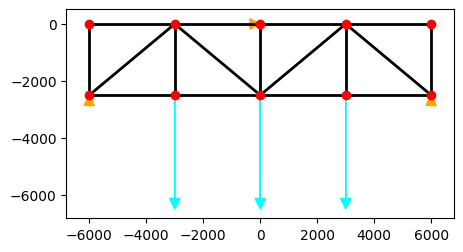

In [117]:
m = truss_model(dvs0)
plots.setup(m)
plots.plot_members(m)
plots.plot_joints(m)
plots.plot_applied_forces(m)
plots.plot_translation_supports(m)
plots.show(m)

The function `model.volume(m)` calculates the total volume of all 
the members of the structure. We can use it to evaluate 
the total mass of the structure. 


In [118]:
mass = RHO * model.volume(m)
print('Initial mass = ', 1000 * mass, ' [kg]')

Initial mass =  60.980984241621556  [kg]


This helper function is defined to compute the design 
responses (`drs`). Static response of the structure is computed. The design 
responses are the mass of the structure and  the maximum displacement magnitude. They are returned as a tuple.


In [119]:
def solve(dvs):
    m = truss_model(dvs)
    model.number_dofs(m)
    model.solve_statics(m)
    drs = (
        RHO * model.volume(m),
        max(abs(m["U"])),
    )
    return drs

Now we can report on the performance of the structure 
as originally designed.


In [120]:
drs = solve(dvs0)
initial_mass = drs[0]
initial_max_deflection = drs[1]
print("\nInitial structure")
print("-----------------")
print("Initial Design Variables: ", dvs0)
print("Mass: ", 1000 * initial_mass, ' [kg]')
print("Initial deflection: ", initial_max_deflection, '[mm]')



Initial structure
-----------------
Initial Design Variables:  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Mass:  60.980984241621556  [kg]
Initial deflection:  9.859401841842457 [mm]


At this point we prepare for the optimization. The objective 
function and the constraints need to be defined. 

In [121]:
# Objective function is the normalized mass.
def objective(dvs):
    drs = solve(dvs)
    return drs[0] / initial_mass

Define a constraint on the maximum deflection.  The constraint here is on the maximum deflection, $(u_{max}-\max u)/u_{max}\ge 0$: Here $u_{max}$=`MAXIMUM_ALLOWED_DEFLECTION`.

In [122]:
def constrain_deflection(dvs):
    drs = solve(dvs)
    max_deflection = drs[1]
    return (MAXIMUM_ALLOWED_DEFLECTION - max_deflection) / MAXIMUM_ALLOWED_DEFLECTION

cons = [
    {"type": "ineq", "fun": constrain_deflection},
]

The function `constrain_deflection` is used to define an inequality constraint. All such constraints are collected in the list `cons`.




Define lower bounds for the design variables. There are no upper bounds (the `None`).


In [123]:
bounds = [(MINIMUM_DV, None) for _ in dvs0]

Invoke the optimization function. 


In [124]:
solution = minimize(
    objective,
    dvs0,
    method="SLSQP",
    bounds=bounds,
    constraints=cons,
    options={"ftol": 1e-7, "maxiter": 1000, "disp": True},
)

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.3076704754532138
            Iterations: 204
            Function evaluations: 4385
            Gradient evaluations: 203


Retrieve the values of the design variables from the solution, and compute the design responses
for the optimal design variables.

In [125]:
dvs = solution.x
drs = solve(dvs)

 Now report the characteristics of the optimized structure. Note that some design variables are equal to `MINIMUM_DV`: this means the lower bound constraint is active. Also, the largest deflection is equal to the maximum allowed, and that constraint is then also active.

In [126]:
mass = drs[0]
max_deflection = drs[1]
print("\nOptimized structure")
print("-----------------")
print("Solution success: ", solution.success, f" ({solution.nit} iterations)")
print("Design Variables: ", dvs)
print("Mass: ", 1000 * mass, ' [kg]')
print("Largest deflection: ", max_deflection, '[mm]')


Optimized structure
-----------------
Solution success:  True  (204 iterations)
Design Variables:  [0.42730807 0.42706983 0.40436727 0.40497801 0.01       0.66385298
 0.66429259 0.01       0.01       0.08446989 0.01       0.08894196
 0.01       0.54040378 0.3029455  0.29809096 0.52094015]
Mass:  18.762048415224644  [kg]
Largest deflection:  20.00000015213451 [mm]


Print out the cross sectional areas (in millimeters square). Note that some of the bars have the smallest possible area.


In [127]:
print("Areas of individual bars in mm**2: ")
m = truss_model(dvs)
a = 0
for _m in m['truss_members'].values():
    print(f"{_m['mid']}: {INITIAL_AREA * dvs[a]}")
    a += 1

Areas of individual bars in mm**2: 
0: 64.09621093880364
1: 64.06047428625251
2: 60.65509124007371
3: 60.746701557031
4: 1.5
5: 99.57794724803531
6: 99.64388820491041
7: 1.5000000000000104
8: 1.5
9: 12.67048288507066
10: 1.5
11: 13.341294305390203
12: 1.5
13: 81.06056660846755
14: 45.4418247750152
15: 44.71364325293679
16: 78.14102294066362


The following visualization provides a graphical assessment of the optimized structure: bars with large cross sectional area are shown with thick lines, and conversely bars whose cross sectional area is small are very thin.

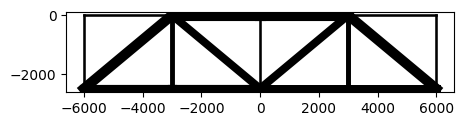

In [128]:
plots.setup(m)
plots.plot_members(m, min_linewidth=1, max_linewidth=8)
plots.show(m)

Notice the null bars in the corners: they have the minimum cross sectional area allowed. Similarly the vertical in the middle. Theoretically these bars are not needed. The vertical in the middle is actually essential, since if that bar was not there, the structure would become a mechanism (its stiffness becomes singular). Even the bars in the corners must be there, i.e. their cross sectional area cannot drop to zero. Since the joints in the corners are not connected to anything else, if the corner bars were not there, the stiffness would again become singular.

## Conclusions

The mass of the optimized structure was reduced to less than one third of the original mass.

For practical reasons, optimizing the cross sectional area of every single bar is probably not very attractive. Nevertheless, it is useful to look at such results. In this case, the optimal structure clearly indicates that there are some parts of the structure which could be entirely omitted (null bars). 